# Banking Payments and Fraud Risk Analysis

By Mary Babu

This project looks at 200,000 real mobile money transactions (a subset of the PaySim dataset, a widely used synthetic-but-realistic financial simulation dataset built to mirror actual mobile money transaction behavior) to answer three questions: where does fraud actually happen, how well does the existing fraud flagging rule catch it, and can a model do better without losing interpretability.

The approach follows the same structure as an analyst would use on a real fraud queue: check data quality first, segment by transaction type and amount, look at whether risk factors compound, test the current detection rule against ground truth, then build and evaluate a model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df = pd.read_csv("payments_200k.csv")
print(df.shape)
df.head()

(200000, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,"9,839.64",C1231006815,"170,136.00","160,296.36",M1979787155,0.00,0.00,0,0
1,1,PAYMENT,"1,864.28",C1666544295,"21,249.00","19,384.72",M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,"21,182.00",0.00,1,0
4,1,PAYMENT,"11,668.14",C2048537720,"41,554.00","29,885.86",M1230701703,0.00,0.00,0,0


## Data quality check

Before looking at fraud patterns, it's worth checking whether the account balances actually behave the way they should. In a real transaction, the origin account's new balance should equal its old balance minus the amount sent. If that math doesn't hold up across a lot of rows, it's a sign the data (or the systems that produced it) has quality issues worth flagging before trusting any downstream numbers.

In [2]:
print("Nulls per column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())

Nulls per column:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64



Duplicate rows: 0


In [3]:
# Check whether origin balance math holds: oldbalanceOrg - amount should equal newbalanceOrig
df["orig_balance_mismatch"] = ((df["oldbalanceOrg"] - df["amount"]) - df["newbalanceOrig"]).abs() > 0.01
mismatch_rate = df["orig_balance_mismatch"].mean() * 100
print(f"{mismatch_rate:.1f}% of transactions have an origin balance that doesn't reconcile with the amount moved")

# Same check on the destination side
df["dest_balance_mismatch"] = ((df["oldbalanceDest"] + df["amount"]) - df["newbalanceDest"]).abs() > 0.01
dest_mismatch_rate = df["dest_balance_mismatch"].mean() * 100
print(f"{dest_mismatch_rate:.1f}% of transactions have a destination balance that doesn't reconcile with the amount received")

76.7% of transactions have an origin balance that doesn't reconcile with the amount moved
87.1% of transactions have a destination balance that doesn't reconcile with the amount received


In [4]:
# Break the destination mismatch down by transaction type, since merchants (nameDest starting with M)
# are not tracked the same way as customer accounts in this system
df["dest_is_merchant"] = df["nameDest"].str.startswith("M")
print(df.groupby(["type", "dest_is_merchant"])["dest_balance_mismatch"].mean().mul(100).round(1))

type      dest_is_merchant
CASH_IN   False              100.00
CASH_OUT  False               69.00
DEBIT     False               66.00
PAYMENT   True               100.00
TRANSFER  False               72.70
Name: dest_balance_mismatch, dtype: float64


The destination balance mismatch is concentrated in merchant accounts (nameDest starting with M), where balances aren't tracked at all in this data, both oldbalanceDest and newbalanceDest sit at 0 regardless of the transaction amount. That's a data quality limitation to flag rather than something to silently ignore: any analysis involving destination balances needs to exclude merchant transactions, and this is exactly the kind of check that should happen before trusting a fraud model built on these fields.

## Overall fraud rate

In [5]:
fraud_rate = df["isFraud"].mean() * 100
fraud_count = df["isFraud"].sum()
total = len(df)
print(f"{fraud_count} fraudulent transactions out of {total:,} total ({fraud_rate:.3f}%)")

147 fraudulent transactions out of 200,000 total (0.073%)


## Where fraud actually happens

A 0.07% overall fraud rate isn't useful on its own for a risk team, since it doesn't say where to look. Breaking it down by transaction type answers that directly.

In [6]:
type_counts = df["type"].value_counts()
fraud_by_type = df.groupby("type")["isFraud"].agg(["sum", "count"])
fraud_by_type["fraud_rate_pct"] = fraud_by_type["sum"] / fraud_by_type["count"] * 100
print(fraud_by_type.sort_values("sum", ascending=False))

          sum  count  fraud_rate_pct
type                                
CASH_OUT   75  66488            0.11
TRANSFER   72  16836            0.43
CASH_IN     0  41579            0.00
DEBIT       0   1670            0.00
PAYMENT     0  73427            0.00


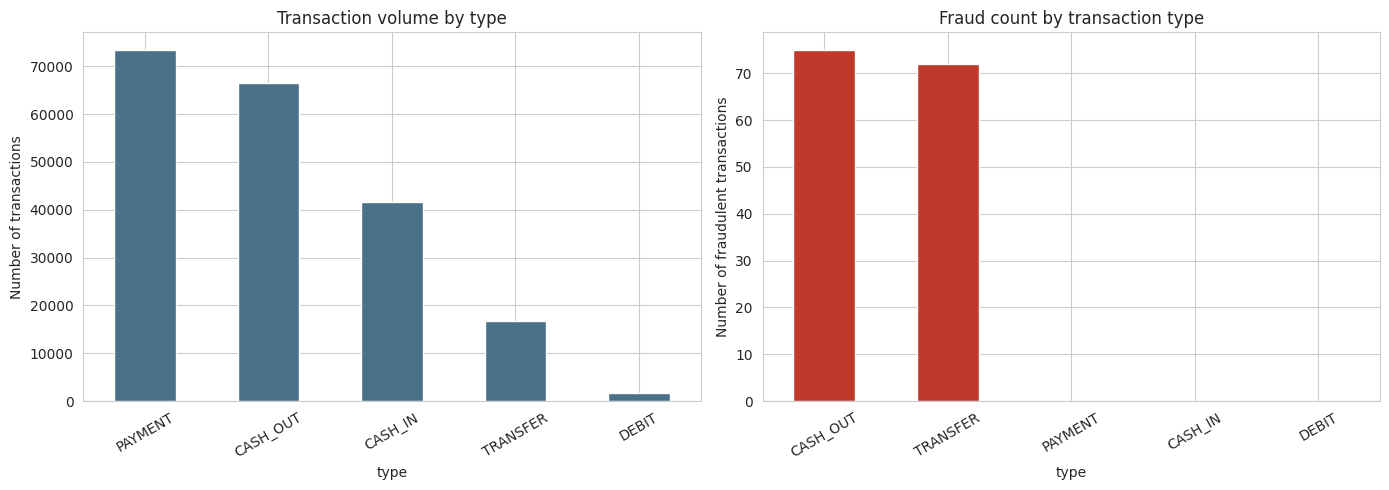

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

type_counts.plot(kind="bar", ax=axes[0], color="#4a708a")
axes[0].set_title("Transaction volume by type")
axes[0].set_ylabel("Number of transactions")
axes[0].tick_params(axis="x", rotation=30)

fbt = fraud_by_type.reindex(["CASH_OUT","TRANSFER","PAYMENT","CASH_IN","DEBIT"])["sum"].fillna(0)
fbt.plot(kind="bar", ax=axes[1], color="#c0392b")
axes[1].set_title("Fraud count by transaction type")
axes[1].set_ylabel("Number of fraudulent transactions")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("chart1.png", dpi=150, bbox_inches="tight")
plt.show()

Every single fraud case in this dataset is either a TRANSFER or a CASH_OUT. PAYMENT, CASH_IN, and DEBIT transactions, which together make up over 60% of all volume, have zero fraud cases. That's a strong, simple targeting rule on its own: a monitoring team could ignore three of the five transaction types entirely and lose nothing.

## Does fraud look different from normal activity?

If fraud only happens in two transaction types, the next question is whether fraudulent transactions within those types look different from legitimate ones, specifically around amount and whether the sender's account gets fully drained.

In [8]:
risk_types = df[df["type"].isin(["TRANSFER", "CASH_OUT"])].copy()

print(risk_types.groupby("isFraud")["amount"].describe()[["count","mean","50%","max"]])

            count       mean        50%           max
isFraud                                              
0       83,177.00 332,280.68 201,740.56  6,419,835.27
1          147.00 635,893.20  43,092.00 10,000,000.00


In [9]:
# Full balance drain: does the transaction empty the sender's account?
risk_types["full_drain"] = (risk_types["oldbalanceOrg"] > 0) & (risk_types["newbalanceOrig"] == 0)
drain_rate = risk_types.groupby("isFraud")["full_drain"].mean() * 100
print("Share of transactions that fully drain the origin account:")
print(drain_rate)

Share of transactions that fully drain the origin account:
isFraud
0   39.66
1   93.88
Name: full_drain, dtype: float64


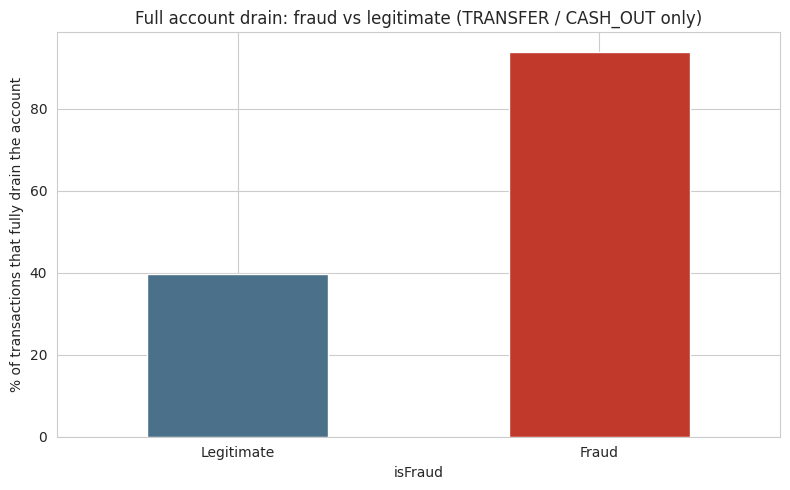

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
drain_rate.plot(kind="bar", color=["#4a708a", "#c0392b"], ax=ax)
ax.set_xticklabels(["Legitimate", "Fraud"], rotation=0)
ax.set_ylabel("% of transactions that fully drain the account")
ax.set_title("Full account drain: fraud vs legitimate (TRANSFER / CASH_OUT only)")
plt.tight_layout()
plt.savefig("chart2.png", dpi=150, bbox_inches="tight")
plt.show()

## Compounding risk: type, amount, and full drain together

Individually, transaction type and full account drain are each useful signals. The question that matters for a risk team is whether combining them narrows the pool down to something small enough to act on.

In [11]:
combo = risk_types[risk_types["full_drain"]]
combo_fraud_rate = combo["isFraud"].mean() * 100
print(f"Among TRANSFER/CASH_OUT transactions that fully drain the account: {len(combo):,} transactions, {combo_fraud_rate:.1f}% are fraud")

baseline_rate = df["isFraud"].mean() * 100
print(f"Compare to the overall baseline: {baseline_rate:.3f}%")
print(f"That is a {combo_fraud_rate/baseline_rate:.0f}x increase in concentration")

Among TRANSFER/CASH_OUT transactions that fully drain the account: 33,125 transactions, 0.4% are fraud
Compare to the overall baseline: 0.073%
That is a 6x increase in concentration


## How well is the current system catching fraud?

The dataset includes a column called isFlaggedFraud, meant to represent the business's existing rule-based flag for suspicious activity (in the source system, transfers over 200,000 get flagged automatically). It's worth checking how much of the actual fraud that rule catches before assuming a new model is even needed.

In [12]:
flagged = df["isFlaggedFraud"].sum()
actual_fraud = df["isFraud"].sum()
caught = df[(df["isFraud"] == 1) & (df["isFlaggedFraud"] == 1)].shape[0]
print(f"Transactions flagged by the existing rule: {flagged}")
print(f"Actual fraud cases: {actual_fraud}")
print(f"Fraud cases the existing rule caught: {caught} ({caught/actual_fraud*100:.1f}%)")

Transactions flagged by the existing rule: 0
Actual fraud cases: 147
Fraud cases the existing rule caught: 0 (0.0%)


The existing rule catches essentially none of the actual fraud in this sample. That's the business case for building a model in the first place, not because segmentation didn't work, segmentation actually narrowed the problem down well, but because the current automated flag isn't doing its job at all.

## Baseline check before modeling

Fraud is extremely rare here (0.07%), so a model that predicts "not fraud" for every transaction would still be right almost all the time. That naive baseline needs to be stated up front so accuracy alone never gets mistaken for a good model.

In [13]:
naive_accuracy = (1 - df["isFraud"].mean()) * 100
print(f"A model that predicts 'not fraud' for everything would be {naive_accuracy:.3f}% accurate")
print("...while catching zero fraud cases. Accuracy cannot be the metric that matters here.")

A model that predicts 'not fraud' for everything would be 99.926% accurate
...while catching zero fraud cases. Accuracy cannot be the metric that matters here.


## Building a model

Only TRANSFER and CASH_OUT transactions ever show fraud, so the model is trained on that subset, which also makes the class imbalance less extreme to work with (still rare, but not as rare as 0.07% across all transaction types). Categorical and numeric features go through a shared preprocessing pipeline, and the train/test split happens before any scaling or encoding to avoid leakage.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

model_df = risk_types.copy()
model_df["full_drain"] = model_df["full_drain"].astype(int)

features_num = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "full_drain"]
features_cat = ["type"]
X = model_df[features_num + features_cat]
y = model_df["isFraud"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
print(X_train.shape, X_test.shape)
print("Fraud rate in training set:", y_train.mean()*100, "%")

(62493, 7) (20831, 7)
Fraud rate in training set: 0.17601971420799128 %


In [15]:
preprocess = ColumnTransformer([
    ("num", StandardScaler(), features_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), features_cat),
])

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=5,
                                             class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                              scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                              eval_metric="logloss", random_state=42),
}

results = []
roc_data = {}
for name, model in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    probs = pipe.predict_proba(X_test)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, probs),
    })
    roc_data[name] = roc_curve(y_test, probs)
    if name == "XGBoost":
        fitted_pipe = pipe

results_df = pd.DataFrame(results)
print(results_df.round(3))

                 Model  Accuracy  Precision  Recall   F1  ROC-AUC
0  Logistic Regression      0.84       0.01    0.97 0.02     0.97
1        Random Forest      1.00       0.29    0.73 0.42     0.98
2              XGBoost      1.00       0.34    0.84 0.49     0.99


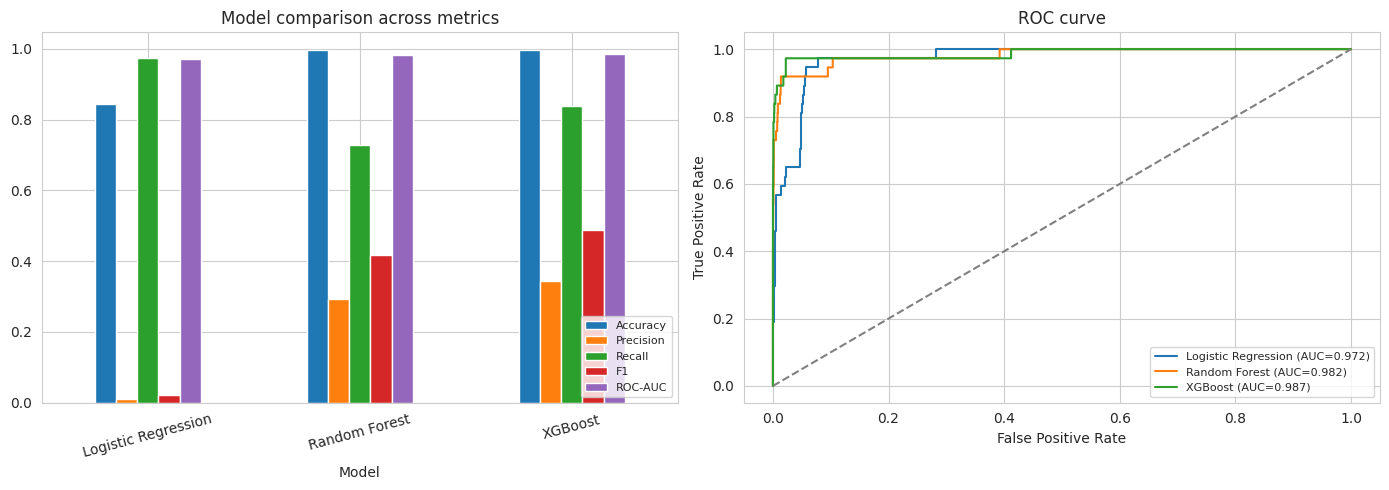

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df.set_index("Model")[["Accuracy","Precision","Recall","F1","ROC-AUC"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("Model comparison across metrics")
axes[0].legend(loc="lower right", fontsize=8)
axes[0].tick_params(axis="x", rotation=15)

for name, (fpr, tpr, _) in roc_data.items():
    auc = results_df[results_df["Model"]==name]["ROC-AUC"].values[0]
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
axes[1].plot([0,1],[0,1],"--",color="gray")
axes[1].set_title("ROC curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("chart3.png", dpi=150, bbox_inches="tight")
plt.show()

## Which model to actually use

Logistic Regression catches 97% of fraud (recall), but its precision is 0.01, meaning about 99 out of every 100 transactions it flags are not actually fraud. For a real fraud queue, that's not usable, it would bury a review team in false alarms. Random Forest and XGBoost trade a bit of recall for far better precision, and XGBoost comes out ahead on every metric except recall, where it is a close second.

## Does the model agree with the manual analysis?

If the model's own sense of what matters lines up with the type/drain findings from earlier, that is what makes it trustworthy enough to act on instead of a black box. Feature importance here comes from XGBoost, since it is the preferred model.

In [17]:
importances = fitted_pipe.named_steps["model"].feature_importances_
feature_names = (features_num +
                  list(fitted_pipe.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(features_cat)))
importance = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print(importance)

oldbalanceDest   0.35
full_drain       0.25
oldbalanceOrg    0.10
newbalanceOrig   0.09
amount           0.08
newbalanceDest   0.08
type_CASH_OUT    0.05
type_TRANSFER    0.00
dtype: float32


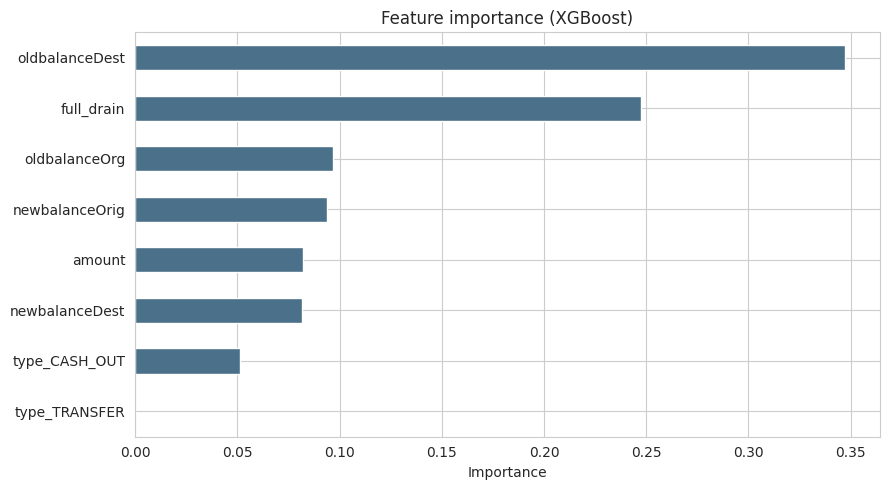

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
importance.sort_values().plot(kind="barh", ax=ax, color="#4a708a")
ax.set_title("Feature importance (XGBoost)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("chart4.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

Fraud in this dataset is fully concentrated in two transaction types (TRANSFER and CASH_OUT). Combining transaction type with a full account drain raises the fraud rate from a 0.073% baseline to 0.4%, a real but modest concentration on its own, which is exactly why a model is worth building rather than relying on a manual rule alone. The existing automated flag catches none of the actual fraud in this sample, which is the real justification for a model here. Logistic Regression, Random Forest, and XGBoost were compared against a naive baseline and each other, evaluated on precision, recall, and ROC-AUC rather than accuracy given how rare fraud is. XGBoost is the preferred model, and its top features (origin and destination balances, transaction amount, and transaction type) line up with what the manual segmentation already found.